# 06 SHAP Analysis

Train a LightGBM model on the full feature set, compute SHAP values on a validation sample, and save a summary plot plus a top-feature table.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from models import make_lightgbm_safe_columns
from preprocessing import build_preprocessor

/home/arand/miniconda3/envs/ds4400/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
processed_dir = PROJECT_ROOT / "data" / "processed"
manifest_path = processed_dir / "feature_definitions.json"
tables_dir = PROJECT_ROOT / "outputs" / "tables"
figures_dir = PROJECT_ROOT / "outputs" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train = pd.read_parquet(processed_dir / "train_features.parquet")
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(train.shape)

(307511, 471)


In [3]:
feature_columns = [column for column in train.columns if column not in ["TARGET", "SK_ID_CURR"]]
X_full = train[feature_columns]
y_full = train["TARGET"]

train_idx, val_idx = train_test_split(
    train.index,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)

X_train_raw = X_full.loc[train_idx].copy()
X_val_raw = X_full.loc[val_idx].copy()
y_train = y_full.loc[train_idx].reset_index(drop=True)
y_val = y_full.loc[val_idx].reset_index(drop=True)

constant_columns = X_train_raw.columns[X_train_raw.nunique(dropna=False) <= 1].tolist()
if constant_columns:
    X_train_raw = X_train_raw.drop(columns=constant_columns)
    X_val_raw = X_val_raw.drop(columns=constant_columns)

numeric_features = X_train_raw.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [column for column in X_train_raw.columns if column not in numeric_features]

tree_preprocessor = build_preprocessor(numeric_features, categorical_features, scale_numeric=False)
X_train_processed = tree_preprocessor.fit_transform(X_train_raw)
X_val_processed = tree_preprocessor.transform(X_val_raw)

original_feature_names = tree_preprocessor.get_feature_names_out().tolist()
safe_feature_names = make_lightgbm_safe_columns(original_feature_names)
safe_to_original = dict(zip(safe_feature_names, original_feature_names))

X_train_model = pd.DataFrame(X_train_processed, columns=safe_feature_names)
X_val_model = pd.DataFrame(X_val_processed, columns=safe_feature_names)

print(X_train_model.shape)
print(X_val_model.shape)

(246008, 593)
(61503, 593)


In [4]:
scale_pos_weight = float((y_train == 0).sum()) / float((y_train == 1).sum())

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_model.fit(X_train_model, y_train)
print("LightGBM model fit complete.")

LightGBM model fit complete.


In [5]:
sample_size = min(2000, len(X_val_model))
shap_sample = X_val_model.sample(n=sample_size, random_state=42)
shap_display_df = shap_sample.copy()
shap_display_df.columns = [safe_to_original[column] for column in shap_display_df.columns]

print(shap_sample.shape)

(2000, 593)


In [6]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_array = shap_values[-1]
else:
    shap_array = shap_values

if hasattr(shap_array, "values"):
    shap_array = shap_array.values

print(shap_array.shape)

(2000, 593)


/home/arand/miniconda3/envs/ds4400/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


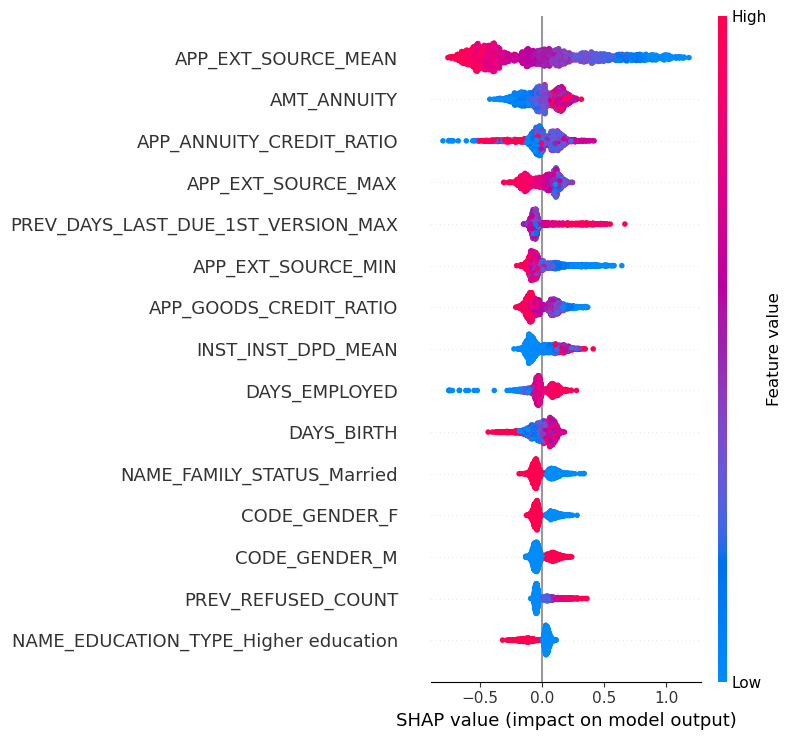

In [7]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_array, shap_display_df, show=False, max_display=15)
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary_lgbm.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
def map_feature_group(feature_name):
    if feature_name.startswith("BUREAU_"):
        return "bureau_family"
    if feature_name.startswith("PREV_"):
        return "previous_application"
    if feature_name.startswith("POS_"):
        return "pos_cash"
    if feature_name.startswith("CC_"):
        return "credit_card"
    if feature_name.startswith("INST_"):
        return "installments"
    return "application"


top_features = pd.DataFrame(
    {
        "feature": shap_display_df.columns,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0),
    }
)
top_features["feature_group"] = top_features["feature"].map(map_feature_group)
top_features = top_features.sort_values("mean_abs_shap", ascending=False).head(10).reset_index(drop=True)
top_features.to_csv(tables_dir / "shap_top_features.csv", index=False)
top_features

,feature,mean_abs_shap,feature_group
0,APP_EXT_SOURCE_MEAN,0.388822,application
1,AMT_ANNUITY,0.113495,application
2,APP_ANNUITY_CREDIT_RATIO,0.104937,application
3,APP_EXT_SOURCE_MAX,0.102210,application
4,PREV_DAYS_LAST_DUE_1ST_VERSION_MAX,0.101409,previous_application
5,APP_EXT_SOURCE_MIN,0.100699,application
6,APP_GOODS_CREDIT_RATIO,0.100054,application
7,INST_INST_DPD_MEAN,0.099241,installments
8,DAYS_EMPLOYED,0.077300,application
9,DAYS_BIRTH,0.073150,application


## Short Conclusions

- Use the top-10 SHAP table to describe whether the model relies mostly on main-application features or aggregated auxiliary-table features.
- If auxiliary features dominate the top of the table, connect that result back to the ablation study.
- Use the SHAP summary plot as the main interpretability figure for the final report.